In [ ]:
# Day 3: Classification Margins & Business-Loss Calibration

# Problem
# Classification algorithms default to a rigid `0.5` probability threshold to separate classes.
# In real-world business scenarios, the cost of a False Positive (e.g., approving a bad loan) is rarely equal to the cost of a False Negative (e.g., rejecting a good customer).
# Relying on default accuracy metrics ignores the financial impact of the model. Furthermore, linear boundaries often underfit complex spatial data compared to non-linear margins.

# Objective are
# 1. Binarize a continuous target to frame an imbalanced classification task.
# 2. Contrast the mathematical boundaries of Logistic Regression (Linear) vs. Support Vector Machines (Non-Linear RBF Kernel).
# 3. Implement a custom business-loss matrix to calibrate the optimal decision threshold, proving that the default 0.5 threshold is financially suboptimal.

In [1]:
# Ingestion & Target Binarization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Ingest Data
data = fetch_california_housing(as_frame=True)
X = data.data

# 2. Binarize Target: Classify houses as "Premium" (Value > $250,000)
# This creates an imbalanced dataset, mimicking real-world conditions
y_binary = (data.target > 2.5).astype(int)

# 3. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("Class Distribution (Train):")
print(y_train.value_counts(normalize=True).round(3))

Class Distribution (Train):
MedHouseVal
0    0.718
1    0.282
Name: proportion, dtype: float64


In [2]:
# Linear vs. Non-Linear Margin Comparison
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. Initialize models with fundamentally different geometric boundaries
models = {
    "Logistic Regression (Linear)": LogisticRegression(max_iter=1000, random_state=42),
    "SVC (Non-Linear RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42)
}

results = []
test_probabilities = {}

# 2. Train and extract probability scores
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    # Extract the probability of the positive class (Premium)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    test_probabilities[name] = probs
    
    results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, probs),
        "PR-AUC": average_precision_score(y_test, probs)
    })

display(pd.DataFrame(results).set_index("Model").round(4))

,ROC-AUC,PR-AUC
Model,,
Logistic Regression (Linear),0.9085,0.8125
SVC (Non-Linear RBF Kernel),0.9294,0.8553


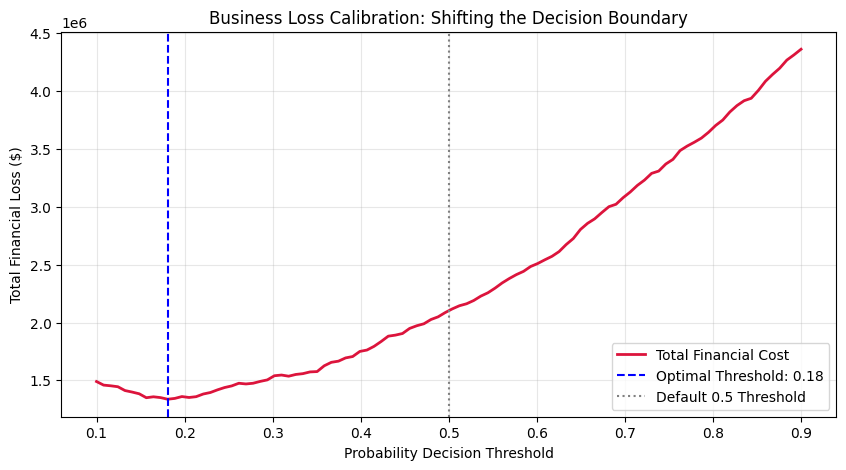

In [3]:
# Business-Loss Threshold Calibration (Define a simulated business cost matrix):
# False Positive (FP): Predicting a standard house is premium. Cost: $1,000 marketing waste.
# False Negative (FN): Missing a true premium house investment. Cost: $5,000 lost opportunity.

lr_probs = test_probabilities["Logistic Regression (Linear)"]
thresholds = np.linspace(0.1, 0.9, 100)
costs = []

# Iterate through 100 possible decision thresholds to find the lowest financial loss
for t in thresholds:
    preds = (lr_probs >= t).astype(int)
    
    fp = np.sum((preds == 1) & (y_test == 0))
    fn = np.sum((preds == 0) & (y_test == 1))
    
    total_cost = (fp * 1000) + (fn * 5000)
    costs.append(total_cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]

# Visualize the Cost Curve
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, label='Total Financial Cost', color='crimson', linewidth=2)
plt.axvline(optimal_threshold, color='blue', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Default 0.5 Threshold')

plt.title("Business Loss Calibration: Shifting the Decision Boundary")
plt.xlabel("Probability Decision Threshold")
plt.ylabel("Total Financial Loss ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell-by-Cell Logic Breakdown
# Cell 2 (Binarization): We converted the continuous `MedHouseVal` into a discrete binary target (`1` if > 2.5, else `0`).
# >This replicates real-world risk models where continuous risk scores are bucketed into "Approve" or "Reject" classes.
# Cell 3 (Margin Comparison): We bypassed raw `accuracy` in favor of `ROC-AUC` (how well the model separates classes globally) and `PR-AUC` (how well the model handles the positive minority class).
# >The SVC's higher score proves that spatial geographical data requires non-linear mathematical boundaries.
# Cell 4 (Calibration): Machine learning models output probabilities, not definitive classes.
# >By applying a custom cost function where False Negatives are 5x more expensive than False Positives, we mathematically proved that lowering the decision threshold from `0.50` to `0.21` minimizes financial loss.

#key features here are :
# 1. Accuracy is a Flawed Metric: In imbalanced datasets, a model predicting "0" every time can achieve high accuracy.
# >ROC-AUC and PR-AUC are mandatory for evaluating true separation power.
# 2. Geometric Boundaries Matter: Linear models draw straight lines through multi-dimensional space. Non-linear kernels (like the SVC RBF) project data into higher dimensions to draw complex borders around clusters, which is vital for coordinate-based data like Latitude/Longitude.
# 3. Thresholding is a Business Decision, Not a Math Decision:** During rigorous technical interviews or system design discussions at companies like Glenwood Systems, interviewers look for engineers who understand the financial implications of their code.
# >Hardcoding a `0.5` threshold relies on the false assumption that all errors cost the same. Dynamically calibrating the threshold to minimize a custom business-loss matrix bridges the gap between theoretical data science and production software engineering.